In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
%matplotlib inline

In [4]:
import matplotlib
print(matplotlib.get_backend())

inline


# Combinações

### Arquivos CSV e tratamento

In [5]:
df = pd.read_csv('/home/lucas/representation-fusion/resultados/combinacoes.csv')

#algumas coisas estavam erradas ao fazer a fusão: alguns estavam trocados 0 e 1 
# resultado invertido 

#1. PKLot, todos os que foram feitos com PKLot estão invertidos
mask_pklot = df['encoder'] == 'PKLot'
df.loc[mask_pklot, 'value'] = 1 - df.loc[mask_pklot, 'value']

#2. Kyoto + classificadores CNR (cameras) 
cameras = [
    'camera1', 'camera2', 'camera3', 'camera4', 'camera5',
    'camera6', 'camera7', 'camera8', 'camera9'
]

mask_kyoto_cnr = (
    (df['encoder'] == 'Kyoto') &
    (df['classificador'].isin(cameras))
)

df.loc[mask_kyoto_cnr, 'value'] = 1 - df.loc[mask_kyoto_cnr, 'value']


# 3. criar uma coluna de n_items (quantos itens tem a combinação)
df["n_items"] = df["combination"].apply(lambda x: str(x).split(",")).apply(len)
df = df[df['fusion_method'] != 'mean_probs']  # remover média pq é igual ao sum

## Contexto

No 1º artigo que foi recusado, publicamos usando sempre 10 modelos para a fusão, uma das recusas e sugestões foi testar com quantidades menores de modelos. Dessa forma, esse teste mostra os resultados com as fusões menores que 10 modelos. 

Como o André sugeriu, não precisavamos testar exatamente todas as combinações, apenas boa parte delas, então as combinações foram feitas da seguinte forma:
- Calcula o número total de combinações
- Pegava 50% delas de forma aleatória
- Exemplo: 
    - fusão de 3 modelos 
    - combinatória entre 10 (nº de modelos) x 3(para a fusão) = 120 possíveis combinações
    - 120 // 2 -> 60 combinações testadas


Sobre as fusões:
- Existem 4 tipos + comparativo:
    - Soma
    - Produto
    - Máximo
    - Votação

Sobre o protocolo de treinamento, foi separado da seguinte forma: Treino Encoder, Treino Classificador, Testes
- PKLot : [CNR1 - CNR9], [CNR1 - CNR9]
- CNR: [PUC, UFPR04, UFPR05], [PUC, UFPR04, UFPR05]
- Kyoto: [PUC, UFPR04, UFPR05, CNR1 - CNR9], [PUC, UFPR04, UFPR05, CNR1 - CNR9]

Os treinos com a base do classificador, poderia ter 5 tamanhos:
- 64
- 128
- 256
- 512 
- 1024

### Acurácia média para o tamanho da combinação

In [6]:
df.columns

Index(['encoder', 'classificador', 'teste', 'batch', 'n_models', 'combination',
       'fusion_method', 'value', 'n_items'],
      dtype='object')

Média da acurácia por tamanho da combinação, pelo batch e pelo encoder

In [7]:
df.groupby(['encoder','batch','n_items'])['value'].mean().reset_index().sort_values(['n_items', 'batch'])

,encoder,batch,n_items,value
0,CNR,64,2,0.830813
45,Kyoto,64,2,0.828377
90,PKLot,64,2,0.895647
9,CNR,128,2,0.864421
54,Kyoto,128,2,0.857206
...,...,...,...,...
80,Kyoto,512,10,0.892572
125,PKLot,512,10,0.925452
44,CNR,1024,10,0.930593
89,Kyoto,1024,10,0.905545


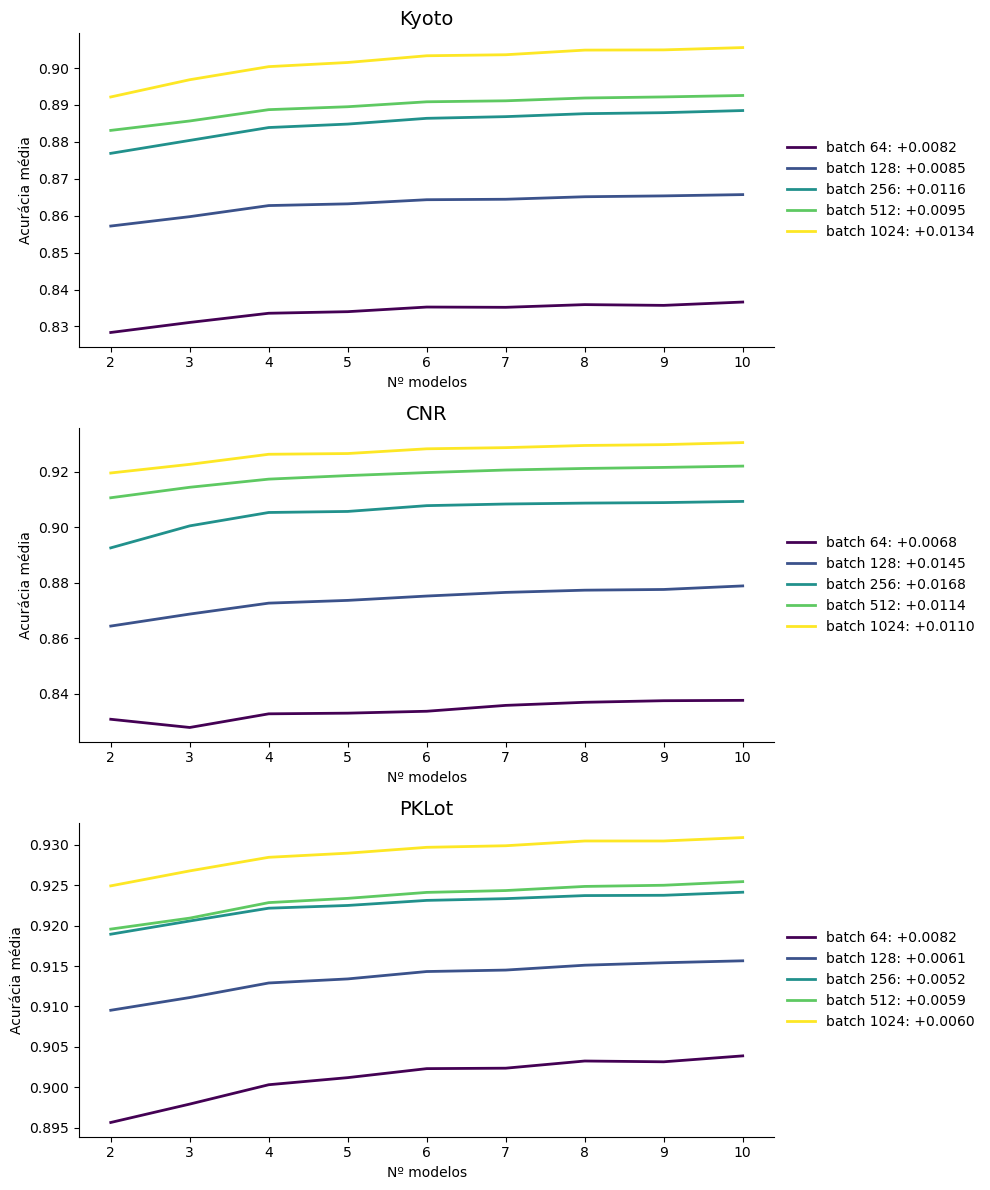

In [8]:
encoders = ['Kyoto', 'CNR', 'PKLot']
batches = [64, 128, 256, 512, 1024]

colors = plt.cm.viridis(np.linspace(0, 1, len(batches)))

fig, axes = plt.subplots(len(encoders), 1, figsize=(10, 12))

for i, encoder in enumerate(encoders):
    
    ax = axes[i]

    for j, batch in enumerate(batches):
        subset = df[
            (df['encoder'] == encoder) &
            (df['batch'] == batch)
        ]

        grouped = (
            subset
            .groupby('n_items')['value']
            .mean()
            .reset_index()
            .sort_values('n_items')
        )

        x = grouped['n_items'].values
        y = grouped['value'].values

        # ganho do primeiro para o último (ex: 2 → 10)
        gain = y[-1] - y[0]

        label = f"batch {batch}: +{gain:.4f}"

        ax.plot(
            x, y,
            label=label,
            color=colors[j],
            linewidth=2
        )

    ax.set_title(f'{encoder}', fontsize=14)
    ax.set_xlabel('Nº modelos')
    ax.set_ylabel('Acurácia média')

    # legenda fora
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    # estilo clean
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Agora analisando caso a caso e vendo se faz diferença ou não o número de combinações aumentar

In [9]:
results = []

group_cols = ['encoder', 'classificador', 'teste', 'batch', 'fusion_method']

for keys, group in df.groupby(group_cols):
    
    group = group.sort_values('n_items')

    val_2  = group[group['n_items'] == 2]['value'].mean()
    val_10 = group[group['n_items'] == 10]['value'].mean()

    diff = val_10 - val_2

    results.append((*keys, val_2, val_10, diff))

df_diff = pd.DataFrame(results, columns=group_cols + ['val_2', 'val_10', 'diff'])

#### maior ganho

In [10]:
max_row = df_diff.loc[df_diff['diff'].idxmax()]
max_row

encoder               CNR
classificador      UFPR04
teste              UFPR05
batch                  64
fusion_method         max
val_2            0.690441
val_10           0.778406
diff             0.087965
Name: 100, dtype: object

#### análise do dataframe de diff

In [11]:
df_diff[df_diff['batch'] == 64].describe()

,batch,val_2,val_10,diff
count,936.0,936.000000,936.000000,936.000000
mean,64.0,0.851757,0.859947,0.008190
std,0.0,0.089289,0.091950,0.009064
min,64.0,0.565813,0.564762,-0.038482
25%,64.0,0.804188,0.813904,0.004371
50%,64.0,0.887052,0.896668,0.008383
75%,64.0,0.920285,0.929670,0.012463
max,64.0,0.961297,0.970522,0.087965


In [12]:
df_diff[df_diff['batch'] == 1024].describe()

,batch,val_2,val_10,diff
count,936.0,936.000000,936.000000,936.000000
mean,1024.0,0.904564,0.915286,0.010722
std,0.0,0.054285,0.051024,0.011445
min,1024.0,0.735612,0.728546,-0.039214
25%,1024.0,0.869106,0.885799,0.004500
50%,1024.0,0.921316,0.930117,0.007853
75%,1024.0,0.946475,0.953136,0.012997
max,1024.0,0.987844,0.989888,0.082084


#### maiores ganhos

In [13]:
df_diff.sort_values('diff', ascending=False).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
100,CNR,UFPR04,UFPR05,64,max,0.690441,0.778406,0.087965
2858,Kyoto,camera9,UFPR04,1024,sum,0.813469,0.895553,0.082084
2857,Kyoto,camera9,UFPR04,1024,mult,0.813469,0.895345,0.081876
2859,Kyoto,camera9,UFPR04,1024,vote,0.813469,0.895005,0.081536
511,Kyoto,UFPR04,camera2,256,vote,0.846287,0.920391,0.074104
510,Kyoto,UFPR04,camera2,256,sum,0.846287,0.920391,0.074104
470,Kyoto,UFPR04,UFPR05,256,sum,0.738811,0.812034,0.073222
509,Kyoto,UFPR04,camera2,256,mult,0.846287,0.919414,0.073127
471,Kyoto,UFPR04,UFPR05,256,vote,0.738811,0.810719,0.071907
932,Kyoto,camera1,UFPR04,512,max,0.712639,0.781639,0.069000


- Os maiores ganhos acontecem sempre entre classificador x teste diferentes
- o que é um bom sinal para cross-domain
- Além disso, 9 dos 10 casos acontece na Kyoto, o que faz com que as fusões no STF (self taught learning) sejam mais impactadas por isso (grande maioria pq os valores estavam mais baixos e a fusão deixa os valores mais consistentes)

In [14]:
#outro exemplo doq falo acima, é que em 5% de ganho, a kyoto é a que mais tem (pode ser impacto por havar mais combinações dela, mas é um indicativo)
df_diff[df_diff['diff'] > 0.05].value_counts('encoder') #mesma coisa acontece com outros valores

encoder
Kyoto    32
CNR       2
Name: count, dtype: int64

#### maiores ganhos acima de 95%

In [15]:
df_diff[df_diff['val_2'] > 0.95].sort_values('diff', ascending=False).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
74,CNR,UFPR04,PUC,512,sum,0.951082,0.967934,0.016853
75,CNR,UFPR04,PUC,512,vote,0.951082,0.967699,0.016617
73,CNR,UFPR04,PUC,512,mult,0.951082,0.967263,0.016181
77,CNR,UFPR04,PUC,1024,mult,0.957259,0.972625,0.015366
2956,Kyoto,camera9,camera4,1024,max,0.956333,0.970922,0.014588
161,CNR,UFPR05,UFPR05,64,mult,0.952435,0.966979,0.014543
78,CNR,UFPR04,PUC,1024,sum,0.957257,0.971432,0.014175
79,CNR,UFPR04,PUC,1024,vote,0.957257,0.971178,0.013920
162,CNR,UFPR05,UFPR05,64,sum,0.952435,0.966250,0.013815
160,CNR,UFPR05,UFPR05,64,max,0.952435,0.966121,0.013686


Nesse cenário, onde estou filtrando apenas para as acurácias altas, os resultados evidenciam
- CNR é a maior predominante
- A fusão melhora apenas 1% em acurácias altas


#### menor diferença

In [16]:
df_diff.sort_values('diff', ascending=True).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
592,Kyoto,UFPR04,camera6,512,max,0.864473,0.812662,-0.051811
652,Kyoto,UFPR04,camera9,512,max,0.794729,0.745218,-0.049511
552,Kyoto,UFPR04,camera4,512,max,0.855720,0.806407,-0.049313
632,Kyoto,UFPR04,camera8,512,max,0.845544,0.798123,-0.047421
476,Kyoto,UFPR04,UFPR05,1024,max,0.800393,0.761179,-0.039214
103,CNR,UFPR04,UFPR05,64,vote,0.690441,0.651959,-0.038482
627,Kyoto,UFPR04,camera8,128,vote,0.790010,0.752325,-0.037684
626,Kyoto,UFPR04,camera8,128,sum,0.790010,0.754194,-0.035816
512,Kyoto,UFPR04,camera2,512,max,0.868010,0.833455,-0.034554
625,Kyoto,UFPR04,camera8,128,mult,0.790010,0.756726,-0.033283


Percebemos que em alguns casos, as fusões acabam piorando a performance, diminuindo até 5% da acurácia 


#### diferença média por encoder

In [17]:
df_diff.groupby(['encoder']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

encoder      diff                              
               mean       std       min       max
0     CNR  0.012087  0.014822 -0.038482  0.087965
1   Kyoto  0.010238  0.011587 -0.051811  0.082084
2   PKLot  0.006281  0.004525 -0.015046  0.032749

#### diferenças pelo método de fusão

In [18]:
df_diff.groupby(['fusion_method']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

fusion_method      diff                              
                     mean       std       min       max
1          mult  0.009750  0.009153 -0.033283  0.081876
0           max  0.009035  0.010639 -0.051811  0.087965
2           sum  0.008799  0.010125 -0.035816  0.082084
3          vote  0.008175  0.010362 -0.038482  0.081536

### Análisando o impacto de um autoencoder na combinação

In [19]:
import ast

df['combination'] = df['combination'].apply(ast.literal_eval)

for i in range(10):
    df[f'model_{i}'] = df['combination'].apply(lambda x: int(i in x))
    
df

,encoder,classificador,teste,batch,n_models,combination,fusion_method,value,n_items,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9
0,PKLot,camera1,camera2,64,2,"(3, 7)",sum,0.938706,2,0,0,0,1,0,0,0,1,0,0
2,PKLot,camera1,camera2,64,2,"(3, 7)",max,0.938706,2,0,0,0,1,0,0,0,1,0,0
3,PKLot,camera1,camera2,64,2,"(3, 7)",mult,0.938706,2,0,0,0,1,0,0,0,1,0,0
4,PKLot,camera1,camera2,64,2,"(3, 7)",vote,0.938706,2,0,0,0,1,0,0,0,1,0,0
5,PKLot,camera1,camera2,64,2,"(1, 9)",sum,0.938217,2,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2960094,Kyoto,camera9,PUC,1024,9,"(0, 2, 3, 4, 5, 6, 7, 8, 9)",vote,0.897823,9,1,0,1,1,1,1,1,1,1,1
2960095,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",sum,0.895574,10,1,1,1,1,1,1,1,1,1,1
2960097,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",max,0.868571,10,1,1,1,1,1,1,1,1,1,1
2960098,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",mult,0.892641,10,1,1,1,1,1,1,1,1,1,1


### Impacto de cada modelo

<Axes: >

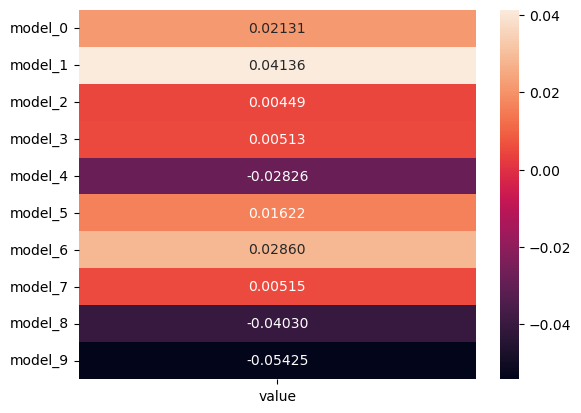

In [20]:
df_filter = df[df['n_items'] == 2]

corr_value = (
    df_filter[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

<Axes: >

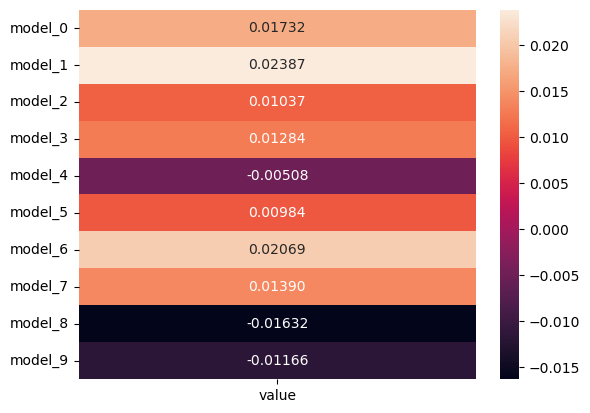

In [21]:
corr_value = (
    df[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

De forma geral, os modelos que mais impactam são o Modelo1 e Modelo6

### Impacto de cada modelo por Batch

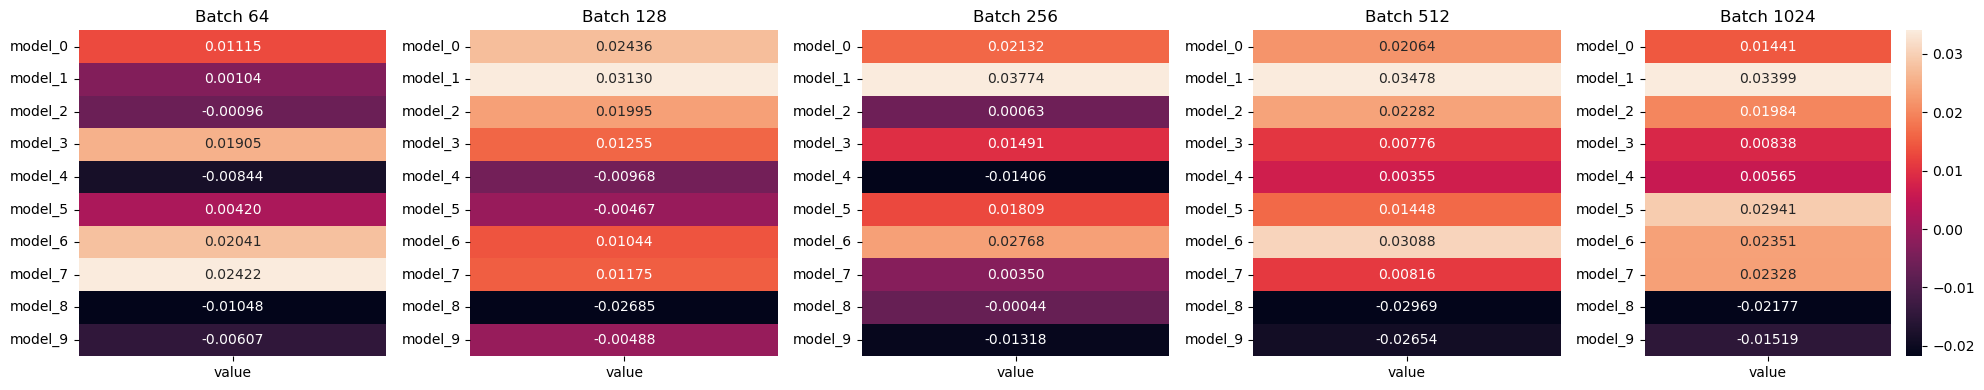

In [22]:
batches = sorted(df['batch'].unique())

fig, axes = plt.subplots(1, len(batches), figsize=(20, 4))

for idx, batch in enumerate(batches):
    ax = axes[idx]

    df_filter = df[df['batch'] == batch]

    corr_value = (
        df_filter[[f'model_{i}' for i in range(10)] + ['value']]
        .corr()['value']
        .drop('value')
    )

    sns.heatmap(
        corr_value.to_frame(),
        annot=True,
        fmt=".5f",
        ax=ax,
        cbar=(idx == len(batches) - 1)  # só um colorbar
    )

    ax.set_title(f'Batch {batch}')

plt.tight_layout()
plt.show()

### Explicações para o impacto de cada modelo:

In [23]:
df_models = pd.read_csv('/home/lucas/representation-fusion/resultados_pibic_ano_passado/precisao.csv')
df_models.head(2)

,modelo,encoder,classificador,teste,batch,value
0,Modelo0,CNR,PUC,PUC,64,0.949582
1,Modelo0,CNR,PUC,PUC,128,0.977535


In [24]:
df_models.groupby(['modelo', 'encoder', 'batch']).agg({'value': ['mean', 'std', 'min', 'max']})

value                              
                           mean       std       min       max
modelo  encoder batch                                        
Modelo0 CNR     64     0.838514  0.106291  0.669674  0.954520
                128    0.889525  0.079081  0.779670  0.977535
                256    0.904671  0.082228  0.758838  0.985605
                512    0.899710  0.092862  0.710150  0.988265
                1024   0.891134  0.089534  0.755994  0.988444
...                         ...       ...       ...       ...
Modelo9 PKLot   64     0.854060  0.060999  0.715443  0.939913
                128    0.888472  0.045682  0.785714  0.955782
                256    0.891866  0.047994  0.779388  0.954281
                512    0.881456  0.055584  0.731976  0.967120
                1024   0.903909  0.048309  0.777537  0.962778

[150 rows x 4 columns]

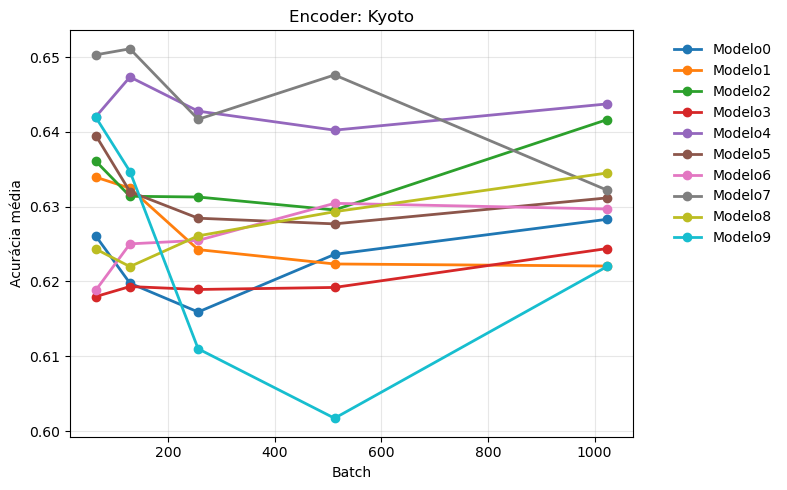

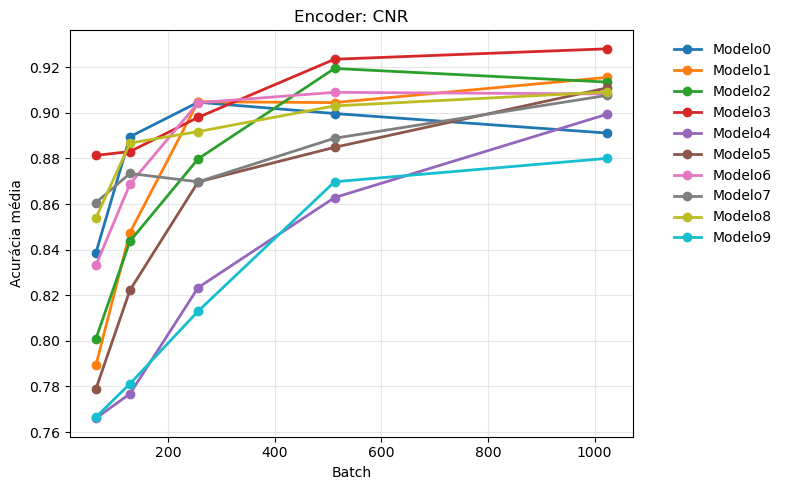

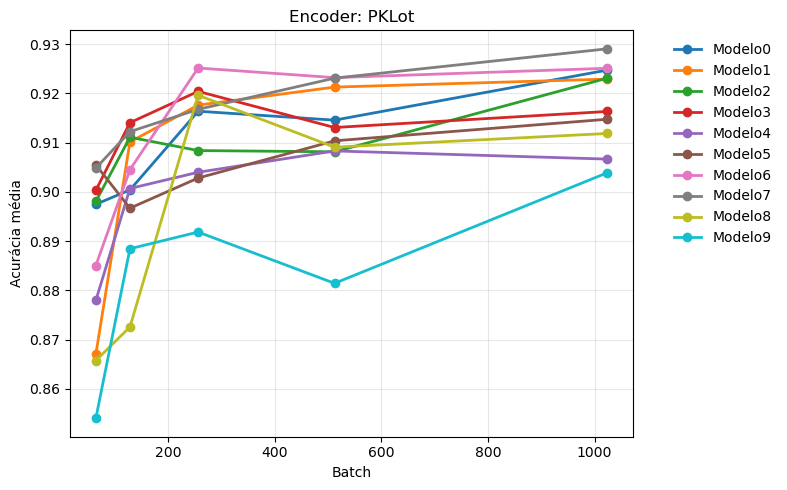

In [33]:
encoders = ['Kyoto', 'CNR', 'PKLot']

for encoder in encoders:
    
    plt.figure(figsize=(8, 5))
    
    subset_encoder = df_models[df_models['encoder'] == encoder]
    
    for model in subset_encoder['modelo'].unique():
        
        subset_model = subset_encoder[
            subset_encoder['modelo'] == model
        ]
        
        grouped = (
            subset_model
            .groupby('batch')['value']
            .mean()
            .reset_index()
            .sort_values('batch')
        )
        
        x = grouped['batch'].values
        y = grouped['value'].values
        
        plt.plot(
            x, y,
            marker='o',
            linewidth=2,
            label=model
        )
    
    plt.title(f'Encoder: {encoder}')
    plt.xlabel('Batch')
    plt.ylabel('Acurácia média')
    
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )
    
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [25]:
df[df['fusion_method'] == 'mult'].groupby(['encoder']).agg({'value': ['mean', 'std', 'min', 'max']})

value                              
             mean       std       min       max
encoder                                        
CNR      0.892423  0.087415  0.588598  0.991175
Kyoto    0.875343  0.079864  0.513685  0.995465
PKLot    0.918468  0.042954  0.676997  0.997732

In [26]:
from tensorflow import keras
from tensorflow.keras import layers
import zipfile
import tempfile
import os
import json

def load_model(model_num):
    """
    Carrega um modelo salvo no formato .keras dado o número do modelo (0-9).
    Retorna o classificador completo e o encoder separadamente.
    Recria o modelo manualmente baseado na config extraída do .keras para lidar com estruturas diferentes.
    """
    path = f"/home/lucas/representation-fusion/Modelos/Modelo_Kyoto-{model_num}/Classificador-PKLot/Estrutura/Classificador_Modelo_Kyoto-{model_num}.keras"

    # Extrair config.json e weights
    with tempfile.TemporaryDirectory() as temp_dir:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.extract('config.json', temp_dir)
            zf.extract('model.weights.h5', temp_dir)
        temp_config = os.path.join(temp_dir, 'config.json')
        temp_weights = os.path.join(temp_dir, 'model.weights.h5')

        with open(temp_config, 'r') as f:
            config = json.load(f)

        # Parse layers
        main_layers = config['config']['layers']
        encoder_layers = main_layers[1]['config']['layers']  # the Functional layers

        # Create encoder
        encoder_input = layers.Input(shape=(64, 64, 3))
        x = encoder_input
        for layer in encoder_layers[1:]:  # skip input
            if layer['class_name'] == 'Conv2D':
                filters = layer['config']['filters']
                x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
            elif layer['class_name'] == 'MaxPooling2D':
                x = layers.MaxPooling2D((2, 2), padding='same')(x)
            elif layer['class_name'] == 'Flatten':
                x = layers.Flatten()(x)
            elif layer['class_name'] == 'Dense':
                units = layer['config']['units']
                activation = layer['config']['activation']
                trainable = layer['config']['trainable']
                x = layers.Dense(units, activation=activation)(x)
        encoder = keras.Model(encoder_input, x, name=f'encoder_{model_num}')
        encoder.trainable = False

        # Create main model (classificador)
        model_input = layers.Input(shape=(64, 64, 3))
        x = encoder(model_input)
        for layer in main_layers[2:]:  # skip input and functional
            if layer['class_name'] == 'Dropout':
                rate = layer['config']['rate']
                x = layers.Dropout(rate)(x)
            elif layer['class_name'] == 'Dense':
                units = layer['config']['units']
                activation = layer['config']['activation']
                x = layers.Dense(units, activation=activation)(x)
        model = keras.Model(model_input, x, name=f'classificadorModelo_Kyoto-{model_num}')

        # Carregar pesos
        model.load_weights(temp_weights)

    return model, encoder

def analisar_modelo(modelo, encoder):
    """
    Analisa o modelo e encoder, retornando informações solicitadas.
    """
    info = {}

    info['modelo'] = modelo.name

    # Total de parâmetros
    info['total_parametros'] = modelo.count_params()

    # Parâmetros do encoder
    info['parametros_encoder'] = encoder.count_params()

    # Camadas de convolução
    info['numero_camadas_convolucao'] = len([layer.name for layer in encoder.layers if isinstance(layer, layers.Conv2D)])

    # Camadas de pool
    info['numero_camadas_pool'] = len([layer.name for layer in encoder.layers if isinstance(layer, layers.MaxPooling2D)])

    # Output shape do encoder
    info['output_shape_encoder'] = np.array(encoder.output.shape)[1:][0]  # remove batch dimension

    # Número de camadas do encoder
    info['numero_camadas_encoder'] = len(encoder.layers)

    return info

values = []
for i, corr in enumerate(corr_value):
    classificador, encoder = load_model(i)
    info = analisar_modelo(classificador, encoder)
    #info['correlacao'] = corr
    values.append(info)

df_info_models = pd.DataFrame(values)
df_info_models['model_num'] = df_info_models['modelo'].apply(lambda x: int(x.split('-')[1]))
df_info_models


2026-04-06 16:04:58.165443: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-06 16:04:58.197570: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-06 16:04:59.451554: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-06 16:05:02.849739: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

,modelo,total_parametros,parametros_encoder,numero_camadas_convolucao,numero_camadas_pool,output_shape_encoder,numero_camadas_encoder,model_num
0,classificadorModelo_Kyoto-0,8083499,7576745,2,2,1849,7,0
1,classificadorModelo_Kyoto-1,1136189,983227,4,3,467,10,1
2,classificadorModelo_Kyoto-2,1860309,1465683,5,3,1411,11,2
3,classificadorModelo_Kyoto-3,3895188,3433234,2,2,1674,7,3
4,classificadorModelo_Kyoto-4,390996,213714,6,5,562,14,4
5,classificadorModelo_Kyoto-5,588407,379637,3,3,685,9,5
6,classificadorModelo_Kyoto-6,21044080,20687598,2,2,1262,7,6
7,classificadorModelo_Kyoto-7,32694874,32159704,3,1,1960,7,7
8,classificadorModelo_Kyoto-8,27784008,27536070,2,2,838,7,8
9,classificadorModelo_Kyoto-9,112830,41532,5,5,148,13,9


In [27]:
df_models['model_num'] = df_models['modelo'].apply(lambda x: int(str(x)[-1]))

In [28]:
df_models.columns

Index(['modelo', 'encoder', 'classificador', 'teste', 'batch', 'value',
       'model_num'],
      dtype='object')

In [29]:
df_models = df_models.merge(df_info_models, on='model_num', how='left', suffixes=('', '_info'))
df_analise = df_models[['model_num', 'encoder', 'classificador', 'teste', 'batch', 'value', 'total_parametros', 'parametros_encoder', 'numero_camadas_convolucao', 'numero_camadas_pool', 'output_shape_encoder', 'numero_camadas_encoder']]
df_analise

,model_num,encoder,classificador,teste,batch,value,total_parametros,parametros_encoder,numero_camadas_convolucao,numero_camadas_pool,output_shape_encoder,numero_camadas_encoder
0,0,CNR,PUC,PUC,64,0.949582,8083499,7576745,2,2,1849,7
1,0,CNR,PUC,PUC,128,0.977535,8083499,7576745,2,2,1849,7
2,0,CNR,PUC,PUC,256,0.985605,8083499,7576745,2,2,1849,7
3,0,CNR,PUC,PUC,512,0.988265,8083499,7576745,2,2,1849,7
4,0,CNR,PUC,PUC,1024,0.988444,8083499,7576745,2,2,1849,7
...,...,...,...,...,...,...,...,...,...,...,...,...
11695,9,PKLot,camera9,camera9,64,0.876404,112830,41532,5,5,148,13
11696,9,PKLot,camera9,camera9,128,0.885233,112830,41532,5,5,148,13
11697,9,PKLot,camera9,camera9,256,0.889446,112830,41532,5,5,148,13
11698,9,PKLot,camera9,camera9,512,0.897673,112830,41532,5,5,148,13


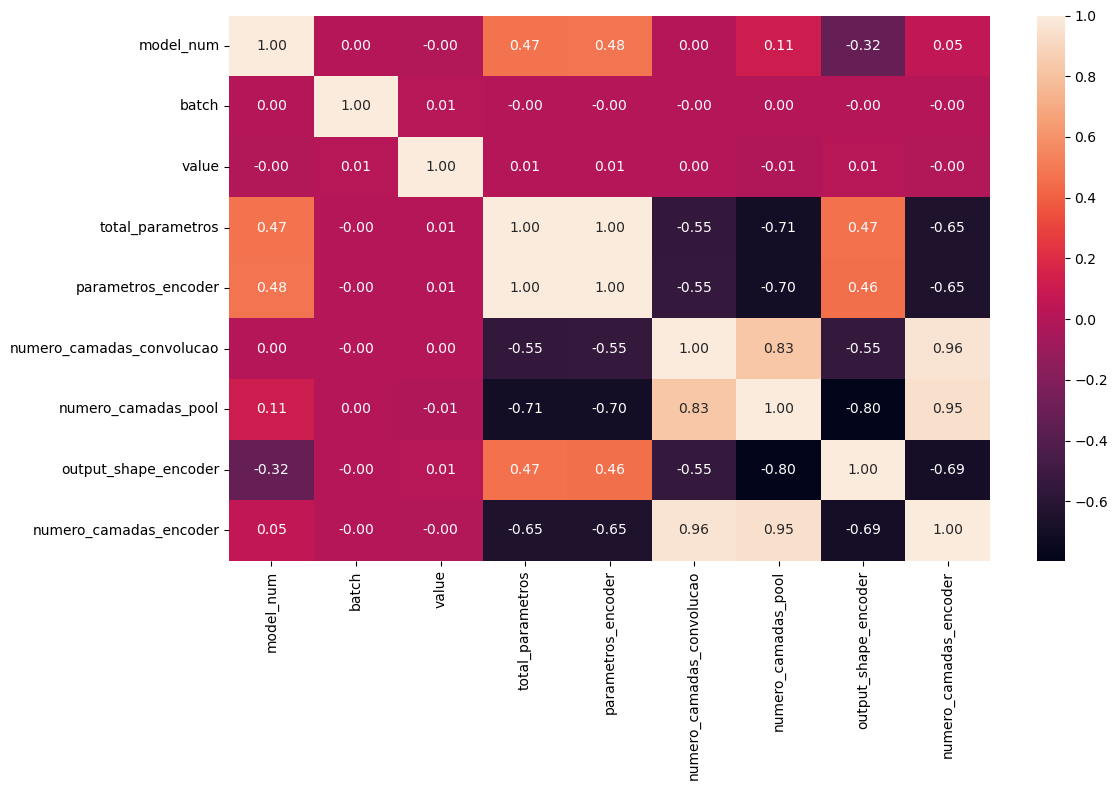

In [30]:
df_num = df_analise.select_dtypes(include=['number'])
corr = df_num.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.tight_layout()

plt.show()